# Aula 4 — SVD: definição e interpretação geométrica
### Valores singulares, vetores singulares, SVD econômica e relação com $A^TA$

**Professor:** Prof. Dr. Rodrigo Figueiredo Abdo

*Curso: Fundamentos de Aprendizado de Máquina Científico para Mecânica dos Fluidos*

## Descrição

Este notebook **complementa** as notas da Aula 4. A decomposição em valores singulares (SVD)
escreve **qualquer** matriz real como $A=U\Sigma V^T$ — uma rotação, um estiramento ao longo de
eixos ortogonais e outra rotação. Vamos calcular a SVD com `numpy`, verificar a reconstrução
**exata**, visualizar como a matriz leva o círculo unitário numa elipse e conferir a relação com
$A^TA$ e $AA^T$.

Nesta aula a reconstrução é **exata**: o truncamento ótimo (Eckart–Young) e a compressão são
assunto da Aula 5; PCA/POD virão nas Aulas 6–7.

## Requisitos

| Biblioteca | Versão mínima | Finalidade |
|---|---|---|
| `numpy` | 1.22 | `numpy.linalg.svd`, autovalores, normas, posto |
| `matplotlib` | 3.5 | visualizações 2D |

```bash
pip install numpy matplotlib
```

In [1]:
# Imports concentrados da aula.
import numpy as np
import matplotlib.pyplot as plt

# A última seção monta uma matriz de dados com um pouco de ruído aleatório.
# Fixamos a semente para que o resultado seja sempre o mesmo a cada execução.
np.random.seed(42)

## Objetivos computacionais

1. Calcular a SVD (`numpy.linalg.svd`) e entender `U, s, Vt`; formas **completa** e **econômica**.
2. Verificar a reconstrução exata $A=U\Sigma V^T$ e a identidade $A\mathbf{v}_i=\sigma_i\mathbf{u}_i$.
3. Visualizar a **geometria**: círculo unitário $\to$ elipse, com semieixos $\sigma_i$ ao longo de
   $\mathbf{u}_i$ (rotação–estiramento–rotação).
4. Confirmar $A^TA\mathbf{v}_i=\sigma_i^2\mathbf{v}_i$, $\|A\|_2=\sigma_1$, $\|A\|_F=\sqrt{\sum\sigma_i^2}$.
5. Ver a SVD como **soma de posto 1** e ler uma pequena **matriz de dados** em termos de modos.

## 1. A SVD em numpy

`np.linalg.svd(A)` devolve `U`, `s` (vetor de valores singulares **decrescentes**) e `Vt`
(que já é $V^T$). Com `full_matrices=False` obtemos a forma **econômica**.

In [2]:
# SVD completa e econômica de uma matriz retangular 3x2.
A = np.array([[1.0, 2.0],
              [3.0, 4.0],
              [5.0, 6.0]])

U, s, Vt = np.linalg.svd(A, full_matrices=True)      # completa
Ue, se, Vte = np.linalg.svd(A, full_matrices=False)  # econômica
print("A é", A.shape)
print("completa:  U", U.shape, " s", s.shape, " Vt", Vt.shape)
print("econômica: U", Ue.shape, " s", se.shape, " Vt", Vte.shape)
print("valores singulares (decrescentes):", s)
print("posto =", np.linalg.matrix_rank(A))

A é (3, 2)
completa:  U (3, 3)  s (2,)  Vt (2, 2)
econômica: U (3, 2)  s (2,)  Vt (2, 2)
valores singulares (decrescentes): [9.52551809 0.51430058]
posto = 2


## 2. Reconstrução exata $A=U\Sigma V^T$

Como `s` é um vetor, precisamos montar a matriz $\Sigma$ (diagonal retangular) para reconstruir.

In [3]:
# O numpy devolve os valores singulares como um VETOR s, não como a matriz Sigma.
# Para reconstruir A = U Sigma V^T precisamos da Sigma "cheia", de tamanho m x n,
# com os valores de s na diagonal e zeros no resto. A função abaixo monta essa matriz.
def monta_sigma(s, shape):
    Sig = np.zeros(shape)      # matriz m x n só de zeros
    np.fill_diagonal(Sig, s)   # escreve os valores singulares na diagonal principal
    return Sig

# Reconstrução pela forma completa: U (m x m), Sigma (m x n) e Vt (n x n).
Sigma = monta_sigma(s, A.shape)
A_rec = U @ Sigma @ Vt
print("A reconstruída == A ?", np.allclose(A_rec, A))

# Reconstrução pela forma econômica. Aqui s tem exatamente min(m, n) valores, então
# np.diag(se) já produz a Sigma quadrada certa (não precisa do bloco de zeros).
A_rec_e = Ue @ np.diag(se) @ Vte
print("Reconstrução econômica == A ?", np.allclose(A_rec_e, A))

A reconstruída == A ? True
Reconstrução econômica == A ? True


## 3. A identidade fundamental $A\mathbf{v}_i=\sigma_i\mathbf{u}_i$

Cada direção de entrada $\mathbf{v}_i$ (coluna de $V$) é levada à direção de saída $\mathbf{u}_i$
(coluna de $U$), escalada por $\sigma_i$.

In [4]:
# Verificar a identidade A v_i = sigma_i u_i (usando a forma econômica).
# O numpy devolve Vt (que é V transposta). Como queremos os vetores singulares à direita
# v_i nas COLUNAS, transpomos de volta: V = Vte.T. Aí V[:, i] é a i-ésima coluna, ou seja v_i.
V = Vte.T

# Para cada i, comparamos o lado esquerdo (A aplicada a v_i) com o lado direito (sigma_i vezes u_i).
# Ue[:, i] é a i-ésima coluna de U, isto é, o vetor singular à esquerda u_i.
for i in range(len(se)):
    lhs = A @ V[:, i]          # A v_i
    rhs = se[i] * Ue[:, i]     # sigma_i u_i
    # A norma da diferença deve ser ~0 (pequenos resíduos vêm do arredondamento de ponto flutuante).
    print(f"i={i}: ||A v_i - sigma_i u_i|| =", np.linalg.norm(lhs - rhs))

i=0: ||A v_i - sigma_i u_i|| = 2.808666774861361e-15
i=1: ||A v_i - sigma_i u_i|| = 1.0853991648152638e-15


## 4. Exemplo completo 2D das notas

$A=\begin{bmatrix}5&4\\0&3\end{bmatrix}$ não é simétrica, mas a SVD existe: as notas obtêm
$\sigma_1=3\sqrt5$, $\sigma_2=\sqrt5$.

In [5]:
# Exemplo da Seção 7 das notas.
A = np.array([[5.0, 4.0], [0.0, 3.0]])
U, s, Vt = np.linalg.svd(A)
print("valores singulares:", s)
print("esperado: 3*sqrt(5) =", 3*np.sqrt(5), " e sqrt(5) =", np.sqrt(5))
print("A^T A =\n", A.T @ A, "\nautovalores de A^T A:", np.linalg.eigvalsh(A.T @ A), "(=> 5 e 45)")

valores singulares: [6.70820393 2.23606798]
esperado: 3*sqrt(5) = 6.708203932499369  e sqrt(5) = 2.23606797749979
A^T A =
 [[25. 20.]
 [20. 25.]] 
autovalores de A^T A: [ 5. 45.] (=> 5 e 45)


## 5. Geometria: círculo unitário $\to$ elipse

A imagem do círculo unitário por $A$ é uma elipse. Seus **semieixos** têm comprimento $\sigma_i$ e
apontam ao longo de $\mathbf{u}_i$; as pré-imagens são as direções $\mathbf{v}_i$.

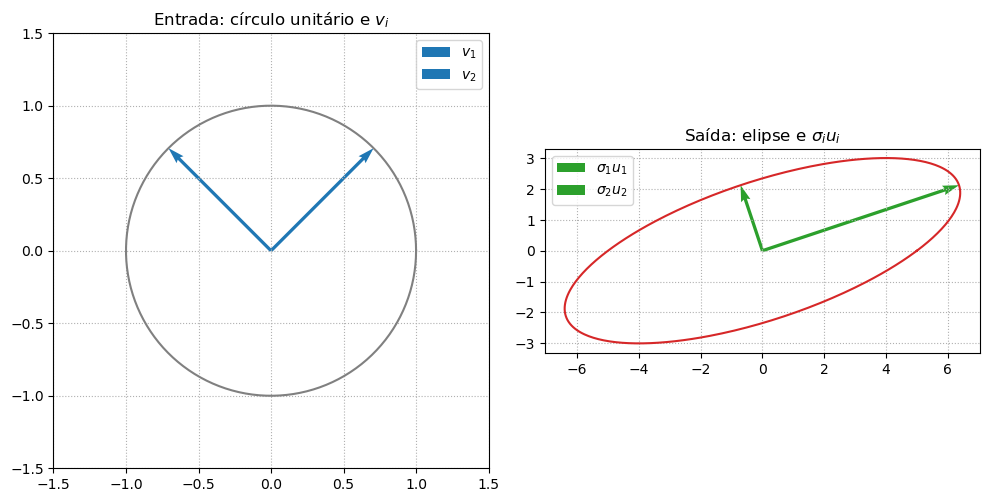

In [6]:
# Visualizar a entrada (círculo unitário + direções v_i) e a saída (elipse + sigma_i u_i).
A = np.array([[5.0, 4.0], [0.0, 3.0]])
U, s, Vt = np.linalg.svd(A)
V = Vt.T   # vetores singulares à direita v_i nas colunas de V

# Desenhamos o círculo unitário ponto a ponto: para 400 ângulos th entre 0 e 2*pi,
# cada ponto do círculo é (cos th, sin th). 'circ' é uma matriz 2x400 (linha 0 = x, linha 1 = y).
th = np.linspace(0, 2*np.pi, 400)
circ = np.array([np.cos(th), np.sin(th)])

# A imagem do círculo por A é uma elipse: aplicamos A a TODOS os pontos de uma vez (A @ circ).
elipse = A @ circ

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 5))

# --- Painel da esquerda: o círculo de entrada e as direções v_1, v_2 ---
ax1.plot(circ[0], circ[1], "gray")
ax1.set_title("Entrada: círculo unitário e $v_i$")
# Desenhamos cada direção como uma seta da origem. Em vez de um laço enxuto, fazemos
# as duas chamadas explícitas (uma por vetor singular à direita), para ficar legível.
# plt.quiver(0, 0, dx, dy) desenha uma seta da origem (0,0) na direção (dx, dy);
# angles/scale_units/scale=1 garantem que a seta tenha o comprimento real do vetor.
ax1.quiver(0, 0, V[0, 0], V[1, 0], angles="xy", scale_units="xy", scale=1,
           color="tab:blue", label="$v_1$")
ax1.quiver(0, 0, V[0, 1], V[1, 1], angles="xy", scale_units="xy", scale=1,
           color="tab:blue", label="$v_2$")
ax1.set_aspect("equal"); ax1.grid(True, ls=":")
ax1.set_xlim(-1.5, 1.5); ax1.set_ylim(-1.5, 1.5); ax1.legend()

# --- Painel da direita: a elipse de saída e os semieixos sigma_i u_i ---
ax2.plot(elipse[0], elipse[1], "tab:red")
ax2.set_title(r"Saída: elipse e $\sigma_i u_i$")
# Cada semieixo da elipse é o vetor singular à esquerda u_i esticado por sigma_i.
# De novo, duas chamadas explícitas (uma por eixo).
ax2.quiver(0, 0, s[0]*U[0, 0], s[0]*U[1, 0], angles="xy", scale_units="xy", scale=1,
           color="tab:green", label=r"$\sigma_1 u_1$")
ax2.quiver(0, 0, s[1]*U[0, 1], s[1]*U[1, 1], angles="xy", scale_units="xy", scale=1,
           color="tab:green", label=r"$\sigma_2 u_2$")
ax2.set_aspect("equal"); ax2.grid(True, ls=":"); ax2.legend()

plt.tight_layout(); plt.show()

## 6. Rotação – estiramento – rotação

Lendo $A=U\Sigma V^T$ da direita para a esquerda, aplicamos a um grid: primeiro $V^T$ (rotação),
depois $\Sigma$ (estiramento nos eixos), depois $U$ (rotação). O resultado é $A$.

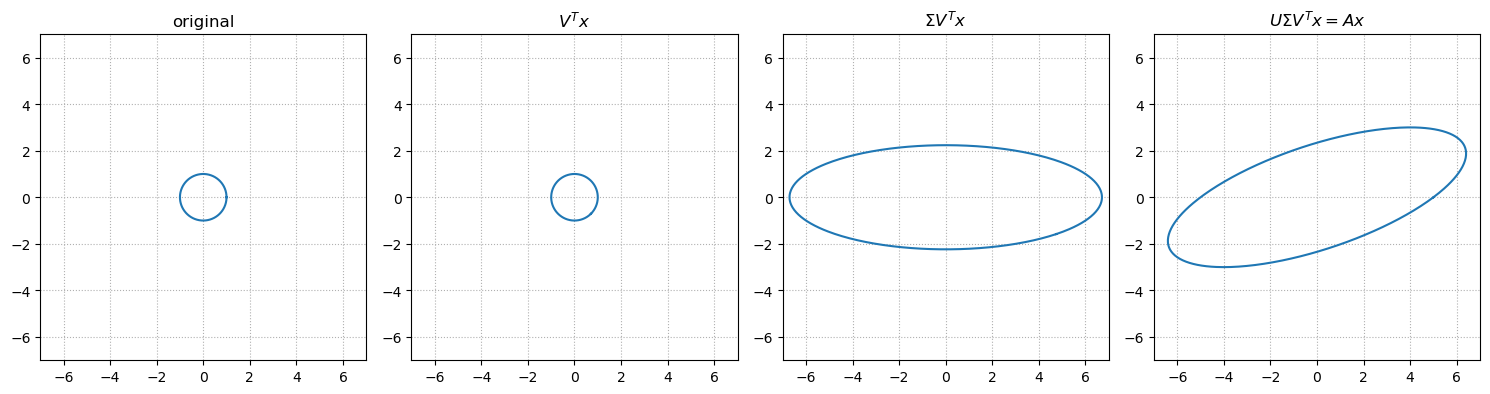

In [7]:
# Os três estágios da SVD aplicados ao círculo unitário, lendo A = U Sigma V^T da direita p/ esquerda.
A = np.array([[5.0, 4.0], [0.0, 3.0]])
U, s, Vt = np.linalg.svd(A)
Sig = np.diag(s)   # Sigma 2x2 (matriz quadrada, pois A é 2x2)

# Mesmo círculo unitário da seção anterior (2x400: linha 0 = x, linha 1 = y).
circ = np.array([np.cos(th), np.sin(th)])

# Aplicamos os fatores um a um, acumulando da direita para a esquerda:
estagio0 = circ                 # círculo original
estagio1 = Vt @ circ            # V^T: rotaciona/reflete a entrada
estagio2 = Sig @ Vt @ circ      # Sigma: estica cada eixo por sigma_i
estagio3 = U @ Sig @ Vt @ circ  # U: rotaciona a saída -> resultado final = A @ circ

# Guardamos cada estágio com seu título numa lista de pares (título, pontos).
estagios = [("original", estagio0),
            (r"$V^T x$", estagio1),
            (r"$\Sigma V^T x$", estagio2),
            (r"$U\Sigma V^T x = Ax$", estagio3)]

fig, axes = plt.subplots(1, 4, figsize=(15, 4))
# zip(axes, estagios) anda em paralelo: a cada passo pega um painel (ax) e um par (t, P);
# o "(t, P)" desempacota o par em título t e pontos P (matriz 2xN).
for ax, (t, P) in zip(axes, estagios):
    ax.plot(P[0], P[1])     # P[0] são os x, P[1] são os y dos pontos da curva
    ax.set_title(t)
    ax.set_aspect("equal"); ax.grid(True, ls=":")
    ax.set_xlim(-7, 7); ax.set_ylim(-7, 7)
plt.tight_layout(); plt.show()

## 7. Relação com $A^TA$ e $AA^T$

Os vetores singulares à direita são autovetores de $A^TA$ e os autovalores são $\sigma_i^2$
(idem $AA^T$ para os da esquerda).

In [8]:
# Os autovalores de A^T A devem ser exatamente os quadrados dos valores singulares (sigma_i^2).
A = np.array([[5.0, 4.0], [0.0, 3.0]])
U, s, Vt = np.linalg.svd(A)

# eigvalsh devolve os autovalores em ordem CRESCENTE. O "[::-1]" inverte a ordem do vetor
# (lê de trás para frente), deixando-o DECRESCENTE para casar com s, que já vem decrescente.
lam = np.sort(np.linalg.eigvalsh(A.T @ A))[::-1]
print("autovalores de A^T A:", lam)
print("sigma_i^2          :", s**2)
print("coincidem?", np.allclose(lam, s**2))

autovalores de A^T A: [45.  5.]
sigma_i^2          : [45.  5.]
coincidem? True


## 8. Normas a partir dos valores singulares

$\|A\|_2=\sigma_1$ (maior estiramento) e $\|A\|_F=\sqrt{\sigma_1^2+\cdots+\sigma_p^2}$.

In [9]:
# Conferir normas via valores singulares.
A = np.array([[5.0, 4.0], [0.0, 3.0]])
s = np.linalg.svd(A, compute_uv=False)
print("||A||_2 = sigma_1 ?", np.isclose(np.linalg.norm(A, 2), s[0]))
print("||A||_F = sqrt(sum sigma^2) ?", np.isclose(np.linalg.norm(A, 'fro'), np.sqrt(np.sum(s**2))))

||A||_2 = sigma_1 ? True
||A||_F = sqrt(sum sigma^2) ? True


## 9. Matriz de posto 1

$A=\mathbf{a}\mathbf{b}^T$ com $\mathbf{a}=(1,2,3)^T$, $\mathbf{b}=(1,2)^T$ tem um **único**
valor singular positivo: $\sigma_1=\sqrt{70}$.

valores singulares: [8.36660027 0.        ]
sigma_1 esperado sqrt(70) = 8.366600265340756 | posto = 1


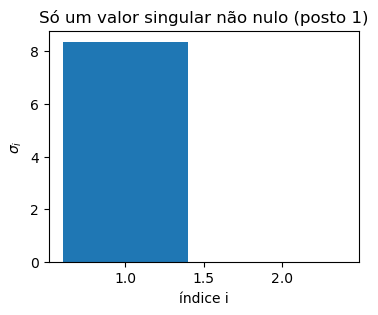

In [10]:
# Matriz de posto 1 das notas: A = a b^T.
a = np.array([1.0, 2.0, 3.0])
b = np.array([1.0, 2.0])

# np.outer(a, b) é o PRODUTO EXTERNO: monta a matriz cuja entrada (i, j) é a[i]*b[j].
# Como toda coluna fica múltipla de a, o resultado tem posto 1.
A = np.outer(a, b)

# compute_uv=False pede ao numpy só os valores singulares (sem calcular U e V).
s = np.linalg.svd(A, compute_uv=False)
print("valores singulares:", np.round(s, 12))
print("sigma_1 esperado sqrt(70) =", np.sqrt(70), "| posto =", np.linalg.matrix_rank(A))

# Gráfico de barras: um único valor singular não nulo confirma o posto 1.
fig, ax = plt.subplots(figsize=(4, 3))
ax.bar(range(1, len(s)+1), s)        # uma barra por valor singular
ax.set_xlabel("índice i")
ax.set_ylabel(r"$\sigma_i$")
ax.set_title("Só um valor singular não nulo (posto 1)")
plt.show()

## 10. SVD como soma de contribuições de posto 1

$A=\sum_{i=1}^r \sigma_i\mathbf{u}_i\mathbf{v}_i^T$. Cada camada acrescenta uma contribuição
direcional; somando todas, recuperamos $A$ exatamente.

soma de todas as camadas == A ? True


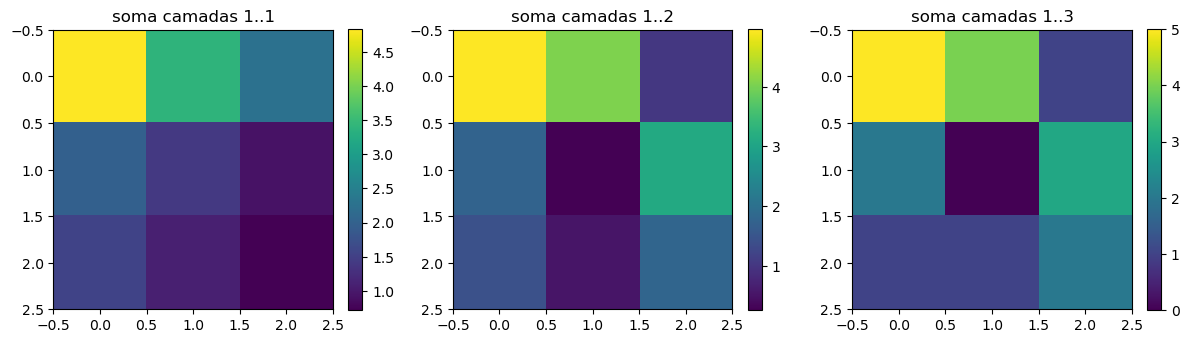

In [11]:
# Reconstruir A acumulando as camadas de posto 1: A = soma_i sigma_i u_i v_i^T.
A = np.array([[5.0, 4.0, 1.0],
              [2.0, 0.0, 3.0],
              [1.0, 1.0, 2.0]])
U, s, Vt = np.linalg.svd(A)
r = len(s)   # número de camadas (uma por valor singular)

# Vamos somar uma camada de cada vez e guardar cada soma parcial para visualizar depois.
acum = []                    # lista com a soma após 1, 2, ..., r camadas
soma = np.zeros_like(A)      # começa em zero e vai recebendo as camadas
for i in range(r):
    # Camada i de posto 1: sigma_i vezes o produto externo u_i v_i^T.
    # U[:, i] é o vetor singular à esquerda u_i; Vt[i, :] é a linha i de V^T, ou seja v_i^T.
    soma = soma + s[i] * np.outer(U[:, i], Vt[i, :])
    acum.append(soma.copy())   # .copy() evita guardar referências ao MESMO array que ainda muda
print("soma de todas as camadas == A ?", np.allclose(acum[-1], A))

# Mapa de calor da reconstrução após acrescentar cada camada.
fig, axes = plt.subplots(1, r, figsize=(4*r, 3.4))
# enumerate(axes) entrega o índice i (0, 1, 2, ...) junto com cada painel ax.
for i, ax in enumerate(axes):
    im = ax.imshow(acum[i], cmap="viridis")
    ax.set_title(f"soma camadas 1..{i+1}")
    fig.colorbar(im, ax=ax, fraction=0.046)
plt.tight_layout(); plt.show()

## 11. Lendo uma matriz de dados com a SVD

Montamos uma pequena matriz de dados $X\in\mathbb{R}^{n\times m}$ (cada coluna é um *snapshot* de um
sinal espacial) a partir de **dois** padrões espaciais. A SVD recupera esses padrões como os
primeiros vetores singulares à esquerda $\mathbf{u}_i$ (os "modos"), as intensidades em $\sigma_i$ e
os coeficientes por snapshot em $V$. (A interpretação como PCA/POD é assunto das próximas aulas.)

In [12]:
# Matriz de dados sintética: 2 padrões espaciais que variam no tempo + um ruído leve.
n, m = 60, 12                      # 60 pontos espaciais (linhas), 12 snapshots no tempo (colunas)
x = np.linspace(0, 2*np.pi, n)     # malha espacial
modo_a = np.sin(x)                 # padrão espacial 1 (uma onda)
modo_b = np.sin(2*x)               # padrão espacial 2 (duas ondas)
t = np.linspace(0, 1, m)           # instantes de tempo (um por snapshot)

# np.outer(modo_a, coef) monta uma matriz n x m: a coluna k é modo_a multiplicado por coef[k].
# Ou seja, cada padrão espacial aparece em todos os snapshots, com peso variando no tempo.
# Somamos os dois padrões e acrescentamos um ruído gaussiano pequeno (semente já fixada no setup).
X = (np.outer(modo_a, np.cos(2*np.pi*t)) +
     0.5*np.outer(modo_b, np.sin(2*np.pi*t)) +
     0.02*np.random.randn(n, m))   # ruído pequeno

# Forma econômica: como temos 2 padrões reais, esperamos 2 valores singulares grandes
# e os demais pequenos (vindos só do ruído).
U, s, Vt = np.linalg.svd(X, full_matrices=False)
print("forma de X:", X.shape, "| 4 maiores sigma:", np.round(s[:4], 3))
print("reconstrução exata?", np.allclose(U @ np.diag(s) @ Vt, X))

forma de X: (60, 12) | 4 maiores sigma: [13.827  6.357  0.205  0.185]
reconstrução exata? True


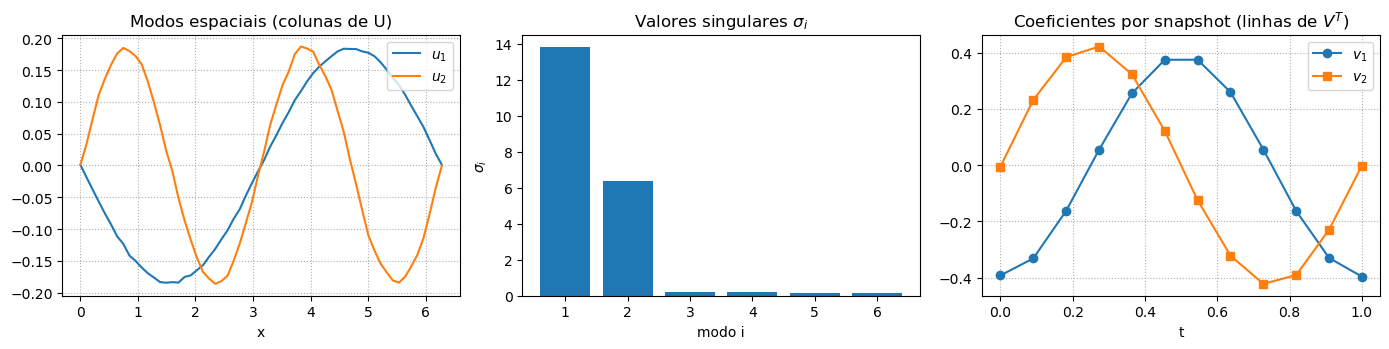

In [13]:
# Visualizar os 2 primeiros modos espaciais e seus coeficientes ao longo dos snapshots.
fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(14, 3.6))

# Modos espaciais = colunas de U. U[:, 0] é u_1 (primeiro modo), U[:, 1] é u_2 (segundo modo).
ax1.plot(x, U[:, 0], label=r"$u_1$")
ax1.plot(x, U[:, 1], label=r"$u_2$")
ax1.set_title("Modos espaciais (colunas de U)")
ax1.set_xlabel("x"); ax1.legend(); ax1.grid(True, ls=":")

# Valores singulares: os dois primeiros se destacam (os dois padrões reais).
ax2.bar(range(1, 7), s[:6])
ax2.set_title(r"Valores singulares $\sigma_i$")
ax2.set_xlabel("modo i"); ax2.set_ylabel(r"$\sigma_i$")

# Coeficientes por snapshot = linhas de V^T. Vt[0, :] é a linha 1 (como o modo 1 evolui no tempo).
ax3.plot(t, Vt[0, :], "o-", label=r"$v_1$")
ax3.plot(t, Vt[1, :], "s-", label=r"$v_2$")
ax3.set_title("Coeficientes por snapshot (linhas de $V^T$)")
ax3.set_xlabel("t"); ax3.legend(); ax3.grid(True, ls=":")

plt.tight_layout(); plt.show()

## Síntese da aula

- A SVD $A=U\Sigma V^T$ existe para **qualquer** matriz real: $V^T$ rotaciona a entrada, $\Sigma$
  estica eixos ortogonais, $U$ rotaciona a saída. A esfera unitária vira um elipsoide com
  semieixos $\sigma_i$.
- $A\mathbf{v}_i=\sigma_i\mathbf{u}_i$; os $\mathbf{v}_i$ são autovetores de $A^TA$ e os
  $\mathbf{u}_i$ de $AA^T$, com autovalores $\sigma_i^2$. Além disso $\|A\|_2=\sigma_1$.
- A forma **econômica/reduzida** reconstrói $A$ **exatamente**; a soma de posto 1
  $A=\sum_i\sigma_i\mathbf{u}_i\mathbf{v}_i^T$ ordena as contribuições por importância.

## Limitações a discutir

- **Sinais não são únicos:** `svd` pode trocar o sinal de pares $(\mathbf{u}_i,\mathbf{v}_i)$;
  compare por valores singulares e por reconstrução, nunca entrada a entrada.
- `eigvalsh(A^T A)` retorna autovalores **crescentes**; alinhe (ordem decrescente) antes de
  comparar com `s`.
- A SVD é **sensível à representação** dos dados: translações, rotações e ondas viajantes podem
  espalhar uma estrutura simples por muitos modos.

## Experimentos sugeridos

1. Use uma matriz $3\times2$ e observe as formas de $U,\Sigma,V$ (completa vs econômica).
2. Confira o Exercício 2 das notas: $A=\begin{bmatrix}0&2\\1&0\end{bmatrix}$.
3. Verifique $\|A\mathbf{v}_1\|_2=\sigma_1$ (Exercício 3).
4. Aumente o ruído da matriz de dados e observe o decaimento dos $\sigma_i$.

*Próxima aula (Aula 5): SVD **truncada** e o teorema de Eckart–Young — a melhor aproximação de
posto baixo, com erro de reconstrução e energia acumulada.*